In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../synthetic_projects_data.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Basic info
print("\nData types and non-null counts:")
print(df.info())

# Class distribution
print("\nClass distribution of review_status:")
print(df["review_status"].value_counts(normalize=True))

First 5 rows:
   project_id project_type_id                                       title  \
0           1     Documentary           Seamless client-driven initiative   
1           2     Documentary  Open-architected clear-thinking moratorium   
2           3            Film          Synergized non-volatile throughput   
3           4            Film                  Realigned stable groupware   
4           5     Documentary     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                          

In [2]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Combine title, description, and synopsis into a single text field
# df["text_data"] = df["title"] + " " + df["description"] + " " + df["synopsis"]

# # Vectorize text using TF-IDF
# tfidf = TfidfVectorizer(max_features=500)  # Limit to 500 most important terms
# text_features = tfidf.fit_transform(df["text_data"]).toarray()

# print("\nShape of TF-IDF Features:")
# print(text_features.shape)  # Rows: samples, Columns: TF-IDF features

from sklearn.feature_extraction.text import TfidfVectorizer
import json

# Function to extract text from crew_roles
def extract_crew_text(crew_roles_str):
    crew_roles = json.loads(crew_roles_str)
    return " ".join([role["role_name"] for role in crew_roles])

# Function to extract text from casting_roles
def extract_casting_text(casting_roles_str):
    casting_roles = json.loads(casting_roles_str)
    text = []
    for role in casting_roles:
        text.append(role["role_name"])
        text.append(role.get("description", ""))  # Include role descriptions
    return " ".join(text)

# Combine all text fields
df["text_data"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["synopsis"] + " " +
    df["crew_roles"].apply(extract_crew_text) + " " +
    df["casting_roles"].apply(extract_casting_text)
)

# Vectorize text using TF-IDF
tfidf = TfidfVectorizer(max_features=500)
text_features = tfidf.fit_transform(df["text_data"]).toarray()

print("\nShape of TF-IDF Features:")
print(text_features.shape)  # Rows: samples, Columns: TF-IDF features


Shape of TF-IDF Features:
(10000, 500)


In [3]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   project_id project_type_id                                       title  \
0           1     Documentary           Seamless client-driven initiative   
1           2     Documentary  Open-architected clear-thinking moratorium   
2           3            Film          Synergized non-volatile throughput   
3           4            Film                  Realigned stable groupware   
4           5     Documentary     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                          

In [4]:
import json
from datetime import datetime

# Safe loading
def safe_json_loads(x):
    if isinstance(x, str):
        return json.loads(x)
    return x

df["production_dates"] = df["production_dates"].apply(safe_json_loads)

# Now define your duration calculation
def calculate_duration(row):
    rehearsal = datetime.strptime(row["rehearsal_date"], "%Y-%m-%d")
    shooting = datetime.strptime(row["shooting_start"], "%Y-%m-%d")
    return (shooting - rehearsal).days

df["rehearsal_to_shooting_days"] = df["production_dates"].apply(calculate_duration)

# Same for other JSON fields
df["crew_roles"] = df["crew_roles"].apply(safe_json_loads)
df["casting_roles"] = df["casting_roles"].apply(safe_json_loads)

# Count roles
df["crew_role_count"] = df["crew_roles"].apply(len)
df["casting_role_count"] = df["casting_roles"].apply(len)

print("\nExtracted Features from JSONB Fields:")
print(df[["rehearsal_to_shooting_days", "crew_role_count", "casting_role_count"]].head())


Extracted Features from JSONB Fields:
   rehearsal_to_shooting_days  crew_role_count  casting_role_count
0                          18                5                   3
1                          32                2                   3
2                          22                4                   4
3                          21                2                   4
4                          11                2                   5


In [5]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=["project_type_id", "package_type_of_user"])

print("\nOne-Hot Encoded Features:")
print(df_encoded.head())


One-Hot Encoded Features:
   project_id                                       title  \
0           1           Seamless client-driven initiative   
1           2  Open-architected clear-thinking moratorium   
2           3          Synergized non-volatile throughput   
3           4                  Realigned stable groupware   
4           5     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                            synopsis  \
0  Hundred agency great hot any. Pressure figure ...   
1  Little dem

In [6]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ["synopsis_plagiarism_similarity", "crew_role_count", "casting_role_count", "rehearsal_to_shooting_days"]

# Scale numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[numerical_features])

print("\nScaled Numerical Features:")
print(scaled_features[:3])  # Show first 3 rows


Scaled Numerical Features:
[[ 0.69612722  1.3453947  -1.32833306 -0.58981131]
 [ 0.02365749 -1.34521532 -1.32833306  1.78081294]
 [-1.11954106  0.44852469 -0.43779065  0.0875099 ]]


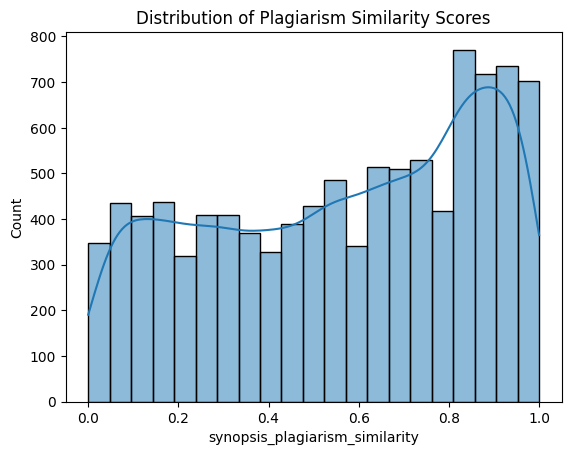

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["synopsis_plagiarism_similarity"], kde=True)
plt.title("Distribution of Plagiarism Similarity Scores")
plt.show()

In [8]:
import numpy as np

# Combine all features
X = np.hstack([
    text_features,  # TF-IDF features
    scaled_features,  # Scaled numerical features
    df_encoded.filter(like="project_type_id").values,  # One-hot encoded project types
    df_encoded.filter(like="package_type_of_user").values  # One-hot encoded packages
])

# Encode target variable
y = df["review_status"].map({"Approved": 0, "Rejected": 1, "Needs Review": 2}).values

print("\nCombined Feature Matrix Shape:")
print(X.shape)  # Rows: samples, Columns: total features


Combined Feature Matrix Shape:
(10000, 512)


In [9]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   project_id project_type_id                                       title  \
0           1     Documentary           Seamless client-driven initiative   
1           2     Documentary  Open-architected clear-thinking moratorium   
2           3            Film          Synergized non-volatile throughput   
3           4            Film                  Realigned stable groupware   
4           5     Documentary     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                          

In [10]:
# from sklearn.model_selection import train_test_split

# # Split into train+validation and test sets
# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # Further split train+validation into train and validation sets
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
# )

# print("\nData Split Sizes:")
# print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


In [11]:
import json
import pandas as pd

# Handle mixed types: str (JSON) or list (already parsed)
def safe_parse_crew_roles(val):
    if isinstance(val, str):
        return json.loads(val)
    return val

# Apply parsing
df["crew_roles"] = df["crew_roles"].apply(safe_parse_crew_roles)

# Function to extract features from crew_roles
def extract_crew_features(roles):
    role_count = len(roles)
    negotiable_count = sum(1 for role in roles if role["compensation"] == "Negotiable")
    numeric_compensations = [
        int(role["compensation"].split("K")[0])
        for role in roles
        if role["compensation"] != "Negotiable"
    ]
    avg_compensation = sum(numeric_compensations) / len(numeric_compensations) if numeric_compensations else 0

    # Binary columns for specific roles
    has_director = 1 if any(role["role_name"] == "Director" for role in roles) else 0
    has_producer = 1 if any(role["role_name"] == "Producer" for role in roles) else 0

    return {
        "crew_role_count": role_count,
        "crew_negotiable_count": negotiable_count,
        "crew_avg_compensation": avg_compensation,
        "has_director": has_director,
        "has_producer": has_producer
    }

# Extract features
crew_features = df["crew_roles"].apply(extract_crew_features).apply(pd.Series)

# Merge extracted features into the original DataFrame
df = pd.concat([df, crew_features], axis=1)

# Display result
print("\nExtracted Crew Role Features:")
print(df[["crew_role_count", "crew_negotiable_count", "crew_avg_compensation", "has_director", "has_producer"]].head())



Extracted Crew Role Features:
   crew_role_count  crew_role_count  crew_negotiable_count  \
0                5              5.0                    1.0   
1                2              2.0                    1.0   
2                4              4.0                    0.0   
3                2              2.0                    0.0   
4                2              2.0                    2.0   

   crew_avg_compensation  has_director  has_producer  
0                  26.25           1.0           0.0  
1                  19.00           0.0           0.0  
2                  31.25           0.0           0.0  
3                  20.50           0.0           0.0  
4                   0.00           0.0           0.0  


In [12]:
import json
import pandas as pd

# Safe parser for mixed formats
def safe_parse_casting_roles(val):
    if isinstance(val, str):
        return json.loads(val)
    return val

# Parse all rows safely
df["casting_roles"] = df["casting_roles"].apply(safe_parse_casting_roles)

# Feature extraction function
def extract_casting_features(roles):
    role_count = len(roles)
    gender_counts = {"Male": 0, "Female": 0, "Non-binary": 0}
    age_range_counts = {"18-25": 0, "26-35": 0, "36-50": 0, "50+": 0}
    negotiable_count = sum(1 for role in roles if role["compensation"] == "Negotiable")

    numeric_compensations = [
        int(role["compensation"].split("K")[0])
        for role in roles
        if role["compensation"] != "Negotiable"
    ]
    avg_compensation = sum(numeric_compensations) / len(numeric_compensations) if numeric_compensations else 0

    for role in roles:
        gender = role.get("gender", "Unknown")
        age_range = role.get("age_range", "Unknown")
        if gender in gender_counts:
            gender_counts[gender] += 1
        if age_range in age_range_counts:
            age_range_counts[age_range] += 1

    return {
        "casting_role_count": role_count,
        "casting_negotiable_count": negotiable_count,
        "casting_avg_compensation": avg_compensation,
        "male_ratio": gender_counts["Male"] / role_count if role_count > 0 else 0,
        "female_ratio": gender_counts["Female"] / role_count if role_count > 0 else 0,
        "non_binary_ratio": gender_counts["Non-binary"] / role_count if role_count > 0 else 0,
        "age_18_25_ratio": age_range_counts["18-25"] / role_count if role_count > 0 else 0,
        "age_26_35_ratio": age_range_counts["26-35"] / role_count if role_count > 0 else 0,
        "age_36_50_ratio": age_range_counts["36-50"] / role_count if role_count > 0 else 0,
        "age_50_plus_ratio": age_range_counts["50+"] / role_count if role_count > 0 else 0
    }

# Extract and convert to DataFrame
casting_features = df["casting_roles"].apply(extract_casting_features).apply(pd.Series)

# Merge extracted features into original DataFrame
df = pd.concat([df, casting_features], axis=1)

# Print preview
print("\nExtracted Casting Role Features:")
print(df[[
    "casting_role_count", "casting_negotiable_count", "casting_avg_compensation", 
    "male_ratio", "female_ratio", "non_binary_ratio", 
    "age_18_25_ratio", "age_26_35_ratio", "age_36_50_ratio", "age_50_plus_ratio"
]].head())



Extracted Casting Role Features:
   casting_role_count  casting_role_count  casting_negotiable_count  \
0                   3                 3.0                       1.0   
1                   3                 3.0                       2.0   
2                   4                 4.0                       2.0   
3                   4                 4.0                       3.0   
4                   5                 5.0                       1.0   

   casting_avg_compensation  male_ratio  female_ratio  non_binary_ratio  \
0                     21.50    0.666667      0.333333          0.000000   
1                     15.00    0.000000      0.333333          0.666667   
2                     30.50    0.750000      0.250000          0.000000   
3                     28.00    0.500000      0.500000          0.000000   
4                     30.75    0.600000      0.200000          0.200000   

   age_18_25_ratio  age_26_35_ratio  age_36_50_ratio  age_50_plus_ratio  
0         0.00

In [13]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   project_id project_type_id                                       title  \
0           1     Documentary           Seamless client-driven initiative   
1           2     Documentary  Open-architected clear-thinking moratorium   
2           3            Film          Synergized non-volatile throughput   
3           4            Film                  Realigned stable groupware   
4           5     Documentary     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                          

In [14]:
# Drop original JSONB columns
df.drop(columns=["crew_roles", "casting_roles"], inplace=True)

# Select all preprocessed features
X = df.drop(columns=["review_status"]).values
y = df["review_status"].map({"Approved": 0, "Rejected": 1, "Needs Review": 2}).values

print("\nFinal Feature Matrix Shape:")
print(X.shape)  # Rows: samples, Columns: total features


Final Feature Matrix Shape:
(10000, 31)


In [15]:
# Display first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   project_id project_type_id                                       title  \
0           1     Documentary           Seamless client-driven initiative   
1           2     Documentary  Open-architected clear-thinking moratorium   
2           3            Film          Synergized non-volatile throughput   
3           4            Film                  Realigned stable groupware   
4           5     Documentary     Reverse-engineered high-level benchmark   

                                         description  start_date    end_date  \
0  Develop process base argue six left always job...  2024-07-23  2024-09-05   
1  Her degree share nothing around career staff.\...  2024-10-23  2025-03-25   
2  Drug age yeah describe result. Office shoulder...  2025-10-27  2026-02-14   
3  Drive sort rest. Student executive but. Or gro...  2025-05-27  2025-10-29   
4  Hard man like. Pay nearly cover million. Alone...  2026-03-18  2026-05-27   

                                          